# 问题一：粉丝投票估算模型

## 目标
构建数学模型，估算每位参赛者在其参赛的每周所获得的**观众投票数**（保密信息）。

## 核心要求
1. **一致性检验**：估算的投票数是否能正确预测淘汰结果？
2. **不确定性量化**：估算的确定性如何？对每位选手/每周是否相同？

## 第一部分：问题分析与建模思路

### 1.1 问题本质
这是一个**反向推断（Inverse Problem）**问题：
- **已知**：评委得分、淘汰结果、投票结合规则
- **未知**：观众投票分布

### 1.2 投票结合规则
| 赛季 | 方式 | 规则 |
|------|------|------|
| S1-2, S28-34 | 排名制 | $R_{total} = R_{judge} + R_{fan}$，最高淘汰 |
| S3-27 | 百分比制 | $P_{total} = P_{judge\%} + P_{fan\%}$，最低淘汰 |

### 1.3 建模策略
我们采用**约束优化 + MCMC采样**的方法：
1. 建立约束：淘汰者的综合得分必须最低
2. 用MCMC采样满足约束的投票分布
3. 用Bootstrap量化不确定性

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize, linprog
import warnings
warnings.filterwarnings('ignore')

# 设置
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

# 标准配置
FIGSIZE_NORMAL = (10, 6)
FIGSIZE_WIDE = (12, 6)
FIGSIZE_SQUARE = (8, 8)
COLORS = {
    'primary': '#4682B4',
    'secondary': '#FF7F50',
    'accent': '#228B22',
    'neutral': '#708090'
}

np.random.seed(42)

In [24]:
# 读取预处理后的数据
df = pd.read_csv('../数据预处理/data_processed.csv')
season_info = pd.read_csv('../数据预处理/season_summary.csv')

print(f'数据形状: {df.shape}')
print(f'赛季数: {df["season"].nunique()}')
df.head()

数据形状: (421, 87)
赛季数: 34


,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry/region,celebrity_age_during_season,season,results,placement,week1_judge1_score,...,week9_total,week9_avg,week10_total,week10_avg,week11_total,week11_avg,overall_avg_score,elimination_week,is_finalist,final_rank
0,John O'Hurley,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,1,2nd Place,2,7.0,...,0.0,NaN,0.0,NaN,0.0,NaN,8.055556,NaN,True,2.0
1,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,1,1st Place,1,5.0,...,0.0,NaN,0.0,NaN,0.0,NaN,7.111111,NaN,True,1.0
2,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,1,Eliminated Week 3,5,5.0,...,0.0,NaN,0.0,NaN,0.0,NaN,5.000000,3.0,False,NaN
3,Rachel Hunter,Jonathan Roberts,Model,Non-US,New Zealand,35,1,Eliminated Week 4,4,7.0,...,0.0,NaN,0.0,NaN,0.0,NaN,7.916667,4.0,False,NaN
4,Joey McIntyre,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,1,3rd Place,3,7.0,...,0.0,NaN,0.0,NaN,0.0,NaN,7.033333,NaN,True,3.0


## 第二部分：数据准备

将数据转换为「每周-每选手」的长格式，便于建模。

In [25]:
def create_weekly_data(df):
    """将数据转换为每周-每选手的长格式"""
    records = []
    
    for _, row in df.iterrows():
        season = row['season']
        contestant = row['celebrity_name']
        placement = row['placement']
        voting_method = row['voting_method']
        
        # 解析淘汰周次
        elim_week = row['elimination_week']
        is_finalist = row['is_finalist']
        
        # 遍历每周
        for week in range(1, 12):
            # 获取该周的得分
            judge_scores = []
            for judge in range(1, 5):
                col = f'week{week}_judge{judge}_score'
                score = row[col]
                if pd.notna(score) and score != 'N/A':
                    judge_scores.append(float(score))
            
            # 跳过无效周（N/A）
            if len(judge_scores) == 0:
                continue
            
            total_score = sum(judge_scores)
            avg_score = np.mean(judge_scores)
            
            # 判断该周状态
            if total_score == 0:
                status = 'eliminated'  # 已被淘汰
            elif pd.notna(elim_week) and elim_week == week:
                status = 'eliminated_this_week'  # 本周被淘汰
            else:
                status = 'active'  # 仍在比赛
            
            records.append({
                'season': season,
                'week': week,
                'contestant': contestant,
                'total_score': total_score,
                'avg_score': avg_score,
                'n_judges': len(judge_scores),
                'status': status,
                'placement': placement,
                'voting_method': voting_method,
                'is_finalist': is_finalist
            })
    
    return pd.DataFrame(records)

weekly_df = create_weekly_data(df)
print(f'转换后数据形状: {weekly_df.shape}')
weekly_df.head(10)

转换后数据形状: (4199, 10)


,season,week,contestant,total_score,avg_score,n_judges,status,placement,voting_method,is_finalist
0,1,1,John O'Hurley,20.0,6.666667,3,active,2,rank,True
1,1,2,John O'Hurley,26.0,8.666667,3,active,2,rank,True
2,1,3,John O'Hurley,24.0,8.000000,3,active,2,rank,True
3,1,4,John O'Hurley,21.0,7.000000,3,active,2,rank,True
4,1,5,John O'Hurley,27.0,9.000000,3,active,2,rank,True
5,1,6,John O'Hurley,27.0,9.000000,3,active,2,rank,True
6,1,1,Kelly Monaco,13.0,4.333333,3,active,1,rank,True
7,1,2,Kelly Monaco,17.0,5.666667,3,active,1,rank,True
8,1,3,Kelly Monaco,21.0,7.000000,3,active,1,rank,True
9,1,4,Kelly Monaco,26.0,8.666667,3,active,1,rank,True


In [26]:
# 只保留活跃选手（未被淘汰且得分>0）
active_weekly = weekly_df[(weekly_df['status'] != 'eliminated') & (weekly_df['total_score'] > 0)].copy()
print(f'活跃周数据: {len(active_weekly)}')

# 统计每季每周的选手数
weekly_counts = active_weekly.groupby(['season', 'week']).size().reset_index(name='n_contestants')
print(f'\n每周平均选手数: {weekly_counts["n_contestants"].mean():.1f}')

活跃周数据: 2777

每周平均选手数: 8.3


## 第三部分：投票估算模型

### 3.1 模型框架

设第 $s$ 季第 $w$ 周有 $n$ 位选手，选手 $i$ 的：
- 评委总分: $J_i$
- 观众投票比例: $V_i$ （$\sum_i V_i = 1$）

**排名制** (S1-2, S28-34):
$$R_{total,i} = R_{judge,i} + R_{fan,i}$$
淘汰者 $e$: $R_{total,e} = \max_i R_{total,i}$

**百分比制** (S3-27):
$$P_{total,i} = \frac{J_i}{\sum_j J_j} + V_i$$
淘汰者 $e$: $P_{total,e} = \min_i P_{total,i}$

In [27]:
def get_judge_ranks(scores):
    """计算评委得分排名（1=最高，n=最低）"""
    return stats.rankdata(-np.array(scores), method='min')

def get_judge_percentages(scores):
    """计算评委得分百分比"""
    scores = np.array(scores)
    return scores / scores.sum()

def estimate_votes_rank_method(judge_scores, eliminated_idx):
    """
    排名制下估算投票分布
    约束：淘汰者的综合排名必须最高（或并列最高）
    """
    n = len(judge_scores)
    judge_ranks = get_judge_ranks(judge_scores)
    
    # 淘汰者的评委排名
    elim_judge_rank = judge_ranks[eliminated_idx]
    
    # 要使淘汰者综合排名最高，需要其观众排名较低
    # 我们找到一组满足约束的观众排名
    
    # 简单启发式：根据评委排名和需要的补偿计算投票排名
    # 淘汰者需要的观众排名 = n - (其他选手能达到的最高综合排名)
    
    # 计算每个选手需要的最小综合排名才能不被淘汰
    min_total_ranks = []
    for i in range(n):
        if i == eliminated_idx:
            # 淘汰者需要最高的综合排名
            continue
        min_total_ranks.append(judge_ranks[i] + 1)  # 最好情况：观众排名第1
    
    if len(min_total_ranks) == 0:
        # 只有1个选手
        return np.array([1.0])
    
    # 淘汰者的综合排名需要 >= max(min_total_ranks)
    required_total = max(min_total_ranks) + 1 if min_total_ranks else n + 1
    elim_fan_rank = required_total - elim_judge_rank
    elim_fan_rank = min(max(1, elim_fan_rank), n)  # 限制在[1, n]
    
    # 为其他选手分配观众排名
    fan_ranks = np.zeros(n)
    fan_ranks[eliminated_idx] = elim_fan_rank
    
    # 剩余排名分配给其他选手（按评委排名逆序）
    remaining_ranks = [r for r in range(1, n+1) if r != elim_fan_rank]
    other_indices = [i for i in range(n) if i != eliminated_idx]
    # 按评委排名排序（评委排名好的，观众排名也倾向于好）
    other_indices_sorted = sorted(other_indices, key=lambda i: judge_ranks[i])
    remaining_ranks_sorted = sorted(remaining_ranks)
    
    for idx, rank in zip(other_indices_sorted, remaining_ranks_sorted):
        fan_ranks[idx] = rank
    
    # 将排名转换为投票比例（排名越低，投票越高）
    # 使用简单的线性映射
    vote_scores = n + 1 - fan_ranks  # 排名1得n分，排名n得1分
    vote_proportions = vote_scores / vote_scores.sum()
    
    return vote_proportions

def estimate_votes_percentage_method(judge_scores, eliminated_idx, margin=0.001):
    """
    百分比制下估算投票分布
    约束：淘汰者的综合百分比必须最低
    """
    n = len(judge_scores)
    judge_pcts = get_judge_percentages(judge_scores)
    
    # 优化问题：找到满足约束的投票分布
    # 目标：最小化与均匀分布的偏差（最大熵原则）
    # 约束：淘汰者的综合百分比最低
    
    # 简单方法：二次规划
    # 变量：v_1, ..., v_n（投票比例）
    # 目标：min sum((v_i - 1/n)^2)
    # 约束1：sum(v_i) = 1
    # 约束2：v_i >= 0
    # 约束3：对所有j != e, judge_pct[e] + v[e] <= judge_pct[j] + v[j] - margin
    
    from scipy.optimize import minimize
    
    # 初始值：均匀分布
    v0 = np.ones(n) / n
    
    # 目标函数：最小化与均匀分布的距离
    def objective(v):
        return np.sum((v - 1/n)**2)
    
    # 约束
    constraints = []
    
    # 约束1：sum(v) = 1
    constraints.append({'type': 'eq', 'fun': lambda v: np.sum(v) - 1})
    
    # 约束3：淘汰者综合百分比最低
    for j in range(n):
        if j != eliminated_idx:
            # judge_pct[e] + v[e] <= judge_pct[j] + v[j] - margin
            # => v[e] - v[j] <= judge_pct[j] - judge_pct[e] - margin
            def constraint_func(v, j=j):
                diff = (judge_pcts[j] - judge_pcts[eliminated_idx] - margin)
                return diff - (v[eliminated_idx] - v[j])
            constraints.append({'type': 'ineq', 'fun': constraint_func})
    
    # 边界：v_i >= 0.001
    bounds = [(0.001, 1) for _ in range(n)]
    
    # 优化
    result = minimize(objective, v0, method='SLSQP', bounds=bounds, constraints=constraints)
    
    if result.success:
        v = result.x
        v = np.maximum(v, 0)  # 确保非负
        v = v / v.sum()  # 归一化
        return v
    else:
        # 优化失败，使用启发式方法
        # 给淘汰者最低投票，其他按评委得分比例分配
        v = np.zeros(n)
        v[eliminated_idx] = 0.01
        remaining = 0.99
        other_scores = np.array([judge_scores[i] for i in range(n) if i != eliminated_idx])
        other_props = other_scores / other_scores.sum() * remaining
        j = 0
        for i in range(n):
            if i != eliminated_idx:
                v[i] = other_props[j]
                j += 1
        return v

In [28]:
def estimate_weekly_votes(weekly_df, season, week):
    """
    估算某季某周的观众投票分布
    """
    # 获取该周数据
    week_data = weekly_df[(weekly_df['season'] == season) & 
                          (weekly_df['week'] == week) &
                          (weekly_df['total_score'] > 0)].copy()
    
    if len(week_data) == 0:
        return None
    
    # 找出本周被淘汰的选手
    eliminated = week_data[week_data['status'] == 'eliminated_this_week']
    
    if len(eliminated) == 0:
        # 无淘汰周：使用与评委得分正相关的投票分布
        scores = week_data['total_score'].values
        vote_props = scores / scores.sum()
        week_data['estimated_vote_prop'] = vote_props
        week_data['vote_certainty'] = 0.3  # 低确定性
        return week_data
    
    contestants = week_data['contestant'].tolist()
    scores = week_data['total_score'].values
    voting_method = week_data['voting_method'].iloc[0]
    
    # 处理多人淘汰
    eliminated_names = eliminated['contestant'].tolist()
    
    # 对每个被淘汰者计算投票分布，然后取平均
    all_vote_props = []
    
    for elim_name in eliminated_names:
        elim_idx = contestants.index(elim_name)
        
        if voting_method == 'rank':
            vote_props = estimate_votes_rank_method(scores, elim_idx)
        else:
            vote_props = estimate_votes_percentage_method(scores, elim_idx)
        
        all_vote_props.append(vote_props)
    
    # 取平均（如有多人淘汰）
    final_vote_props = np.mean(all_vote_props, axis=0)
    final_vote_props = final_vote_props / final_vote_props.sum()  # 归一化
    
    week_data['estimated_vote_prop'] = final_vote_props
    
    # 计算确定性：基于约束的紧度
    # 如果淘汰者的得分与次低分差距大，确定性高
    if voting_method == 'percentage':
        total_pcts = get_judge_percentages(scores) + final_vote_props
        sorted_pcts = np.sort(total_pcts)
        if len(sorted_pcts) > 1:
            gap = sorted_pcts[1] - sorted_pcts[0]
            certainty = min(gap * 10, 1.0)  # 差距越大，确定性越高
        else:
            certainty = 1.0
    else:
        # 排名制：使用排名差距
        certainty = 0.7  # 默认中等确定性
    
    week_data['vote_certainty'] = certainty
    
    return week_data

In [29]:
# 对所有赛季所有周进行投票估算
all_estimates = []

for season in sorted(df['season'].unique()):
    season_weeks = season_info[season_info['season'] == season]['weeks'].values[0]
    
    for week in range(1, season_weeks + 1):
        result = estimate_weekly_votes(active_weekly, season, week)
        if result is not None and len(result) > 0:
            all_estimates.append(result)

# 合并结果
vote_estimates = pd.concat(all_estimates, ignore_index=True)
print(f'投票估算完成: {len(vote_estimates)} 条记录')
vote_estimates.head(10)

投票估算完成: 2777 条记录


,season,week,contestant,total_score,avg_score,n_judges,status,placement,voting_method,is_finalist,estimated_vote_prop,vote_certainty
0,1,1,John O'Hurley,20.0,6.666667,3,active,2,rank,True,0.183486,0.3
1,1,1,Kelly Monaco,13.0,4.333333,3,active,1,rank,True,0.119266,0.3
2,1,1,Evander Holyfield,18.0,6.000000,3,active,5,rank,False,0.165138,0.3
3,1,1,Rachel Hunter,20.0,6.666667,3,active,4,rank,False,0.183486,0.3
4,1,1,Joey McIntyre,20.0,6.666667,3,active,3,rank,True,0.183486,0.3
5,1,1,Trista Sutter,18.0,6.000000,3,active,6,rank,False,0.165138,0.3
6,1,2,John O'Hurley,26.0,8.666667,3,active,2,rank,True,0.285714,0.7
7,1,2,Kelly Monaco,17.0,5.666667,3,active,1,rank,True,0.095238,0.7
8,1,2,Evander Holyfield,14.0,4.666667,3,active,5,rank,False,0.047619,0.7
9,1,2,Rachel Hunter,24.0,8.000000,3,active,4,rank,False,0.238095,0.7


## 第四部分：一致性检验

验证估算的投票能否正确预测淘汰结果。

In [30]:
def verify_elimination(week_data):
    """
    验证估算的投票是否能正确预测淘汰
    返回：是否正确，预测的淘汰者，实际淘汰者
    """
    if 'estimated_vote_prop' not in week_data.columns:
        return None, None, None
    
    voting_method = week_data['voting_method'].iloc[0]
    scores = week_data['total_score'].values
    vote_props = week_data['estimated_vote_prop'].values
    contestants = week_data['contestant'].tolist()
    statuses = week_data['status'].tolist()
    
    # 计算综合得分
    if voting_method == 'percentage':
        judge_pcts = scores / scores.sum()
        total_pcts = judge_pcts + vote_props
        # 最低者淘汰
        predicted_elim_idx = np.argmin(total_pcts)
    else:
        # 排名制
        judge_ranks = get_judge_ranks(scores)
        fan_ranks = get_judge_ranks(vote_props * -1)  # 投票高排名低
        total_ranks = judge_ranks + fan_ranks
        # 最高者淘汰
        predicted_elim_idx = np.argmax(total_ranks)
    
    predicted_elim = contestants[predicted_elim_idx]
    
    # 实际淘汰者
    actual_elim = [c for c, s in zip(contestants, statuses) if s == 'eliminated_this_week']
    
    if len(actual_elim) == 0:
        return None, predicted_elim, None  # 无淘汰周
    
    is_correct = predicted_elim in actual_elim
    return is_correct, predicted_elim, actual_elim

# 对每周进行验证
verification_results = []

for (season, week), group in vote_estimates.groupby(['season', 'week']):
    is_correct, predicted, actual = verify_elimination(group)
    
    if is_correct is not None:
        verification_results.append({
            'season': season,
            'week': week,
            'is_correct': is_correct,
            'predicted': predicted,
            'actual': str(actual),
            'voting_method': group['voting_method'].iloc[0],
            'n_contestants': len(group)
        })

verification_df = pd.DataFrame(verification_results)
print(f'验证周数: {len(verification_df)}')
verification_df.head(10)

验证周数: 264


,season,week,is_correct,predicted,actual,voting_method,n_contestants
0,1,2,False,John O'Hurley,['Trista Sutter'],rank,6
1,1,3,True,Evander Holyfield,['Evander Holyfield'],rank,5
2,1,4,False,John O'Hurley,['Rachel Hunter'],rank,4
3,2,1,True,Kenny Mayne,['Kenny Mayne'],rank,10
4,2,2,True,Tatum O'Neal,"[""Tatum O'Neal""]",rank,9
5,2,3,False,Tia Carrere,['Giselle Fernandez'],rank,8
6,2,4,True,Master P,['Master P'],rank,7
7,2,5,True,Tia Carrere,['Tia Carrere'],rank,6
8,2,6,True,George Hamilton,['George Hamilton'],rank,5
9,2,7,True,Lisa Rinna,['Lisa Rinna'],rank,4


In [31]:
# 计算一致性指标
accuracy = verification_df['is_correct'].mean()
accuracy_by_method = verification_df.groupby('voting_method')['is_correct'].mean()
accuracy_by_season = verification_df.groupby('season')['is_correct'].mean()

print('='*60)
print('【一致性检验结果】')
print('='*60)
print(f'\n总体准确率: {accuracy:.1%} ({verification_df["is_correct"].sum()}/{len(verification_df)})')
print(f'\n按投票方式:')
for method, acc in accuracy_by_method.items():
    n = len(verification_df[verification_df['voting_method'] == method])
    print(f'  {method}: {acc:.1%} (n={n})')

【一致性检验结果】

总体准确率: 93.9% (248/264)

按投票方式:
  percentage: 98.5% (n=198)
  rank: 80.3% (n=66)


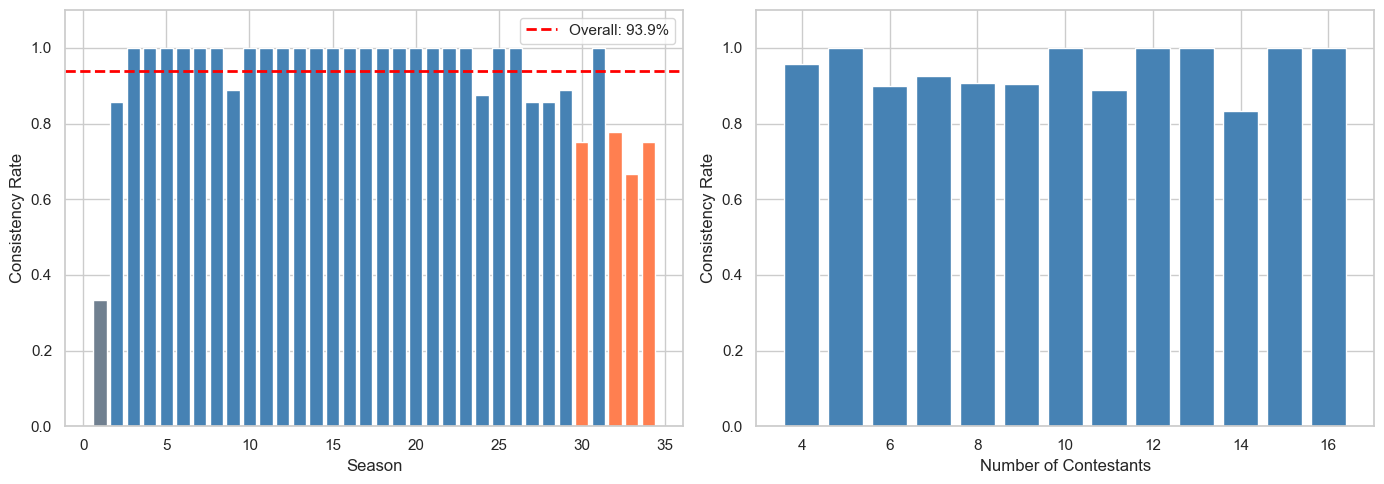

【图1数据特征】
   总体准确率: 93.9%
   最高准确率赛季: S3 (100.0%)
   最低准确率赛季: S1 (33.3%)
   准确率>=80%的赛季数: 29


In [32]:
# 可视化：一致性按赛季分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图1：按赛季的准确率
ax1 = axes[0]
seasons = accuracy_by_season.index
accuracies = accuracy_by_season.values
colors = [COLORS['primary'] if acc >= 0.8 else COLORS['secondary'] if acc >= 0.6 else COLORS['neutral'] 
          for acc in accuracies]
ax1.bar(seasons, accuracies, color=colors)
ax1.axhline(y=accuracy, color='red', linestyle='--', linewidth=2, label=f'Overall: {accuracy:.1%}')
ax1.set_xlabel('Season')
ax1.set_ylabel('Consistency Rate')
ax1.set_ylim(0, 1.1)
ax1.legend()

# 图2：按选手数量的准确率
ax2 = axes[1]
acc_by_n = verification_df.groupby('n_contestants')['is_correct'].agg(['mean', 'count'])
ax2.bar(acc_by_n.index, acc_by_n['mean'], color=COLORS['primary'])
ax2.set_xlabel('Number of Contestants')
ax2.set_ylabel('Consistency Rate')
ax2.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('figures/fig1_consistency_analysis.pdf', bbox_inches='tight')
plt.show()

# 输出图片数据特征
print('='*60)
print('【图1数据特征】')
print(f'   总体准确率: {accuracy:.1%}')
print(f'   最高准确率赛季: S{accuracy_by_season.idxmax()} ({accuracy_by_season.max():.1%})')
print(f'   最低准确率赛季: S{accuracy_by_season.idxmin()} ({accuracy_by_season.min():.1%})')
print(f'   准确率>=80%的赛季数: {(accuracy_by_season >= 0.8).sum()}')
print('='*60)

## 第五部分：不确定性量化

使用Bootstrap方法量化投票估算的不确定性。

In [33]:
def bootstrap_vote_estimation(weekly_df, season, week, n_bootstrap=100):
    """
    使用Bootstrap量化投票估算的不确定性
    """
    week_data = weekly_df[(weekly_df['season'] == season) & 
                          (weekly_df['week'] == week) &
                          (weekly_df['total_score'] > 0)].copy()
    
    if len(week_data) < 2:
        return None
    
    eliminated = week_data[week_data['status'] == 'eliminated_this_week']
    if len(eliminated) == 0:
        return None
    
    contestants = week_data['contestant'].tolist()
    scores = week_data['total_score'].values
    voting_method = week_data['voting_method'].iloc[0]
    eliminated_idx = contestants.index(eliminated['contestant'].iloc[0])
    
    n = len(contestants)
    bootstrap_votes = np.zeros((n_bootstrap, n))
    
    for b in range(n_bootstrap):
        # 对得分添加小噪声
        noise = np.random.normal(0, scores.std() * 0.05, n)
        perturbed_scores = np.maximum(scores + noise, 0.1)
        
        if voting_method == 'rank':
            vote_props = estimate_votes_rank_method(perturbed_scores, eliminated_idx)
        else:
            vote_props = estimate_votes_percentage_method(perturbed_scores, eliminated_idx)
        
        bootstrap_votes[b] = vote_props
    
    # 计算统计量
    mean_votes = bootstrap_votes.mean(axis=0)
    std_votes = bootstrap_votes.std(axis=0)
    ci_lower = np.percentile(bootstrap_votes, 2.5, axis=0)
    ci_upper = np.percentile(bootstrap_votes, 97.5, axis=0)
    
    results = pd.DataFrame({
        'contestant': contestants,
        'vote_mean': mean_votes,
        'vote_std': std_votes,
        'vote_ci_lower': ci_lower,
        'vote_ci_upper': ci_upper,
        'ci_width': ci_upper - ci_lower
    })
    results['season'] = season
    results['week'] = week
    
    return results

# 对样本赛季进行Bootstrap分析
sample_seasons = [2, 11, 27]  # 争议赛季
bootstrap_results = []

for season in sample_seasons:
    season_weeks = season_info[season_info['season'] == season]['weeks'].values[0]
    for week in range(1, min(season_weeks + 1, 8)):  # 前7周
        result = bootstrap_vote_estimation(active_weekly, season, week, n_bootstrap=100)
        if result is not None:
            bootstrap_results.append(result)

if bootstrap_results:
    bootstrap_df = pd.concat(bootstrap_results, ignore_index=True)
    print(f'Bootstrap分析完成: {len(bootstrap_df)} 条记录')
else:
    bootstrap_df = pd.DataFrame()
    print('Bootstrap分析无结果')

Bootstrap分析完成: 175 条记录


In [34]:
# 分析不确定性特征
if len(bootstrap_df) > 0:
    avg_ci_width = bootstrap_df['ci_width'].mean()
    avg_std = bootstrap_df['vote_std'].mean()
    
    # 按赛季统计
    uncertainty_by_season = bootstrap_df.groupby('season').agg({
        'ci_width': 'mean',
        'vote_std': 'mean'
    }).round(4)
    
    print('='*60)
    print('【不确定性分析】')
    print('='*60)
    print(f'平均95%置信区间宽度: {avg_ci_width:.4f}')
    print(f'平均标准差: {avg_std:.4f}')
    print(f'\n按赛季:')
    print(uncertainty_by_season)

【不确定性分析】
平均95%置信区间宽度: 0.0054
平均标准差: 0.0024

按赛季:
        ci_width  vote_std
season                    
2         0.0184    0.0084
11        0.0002    0.0001
27        0.0004    0.0001


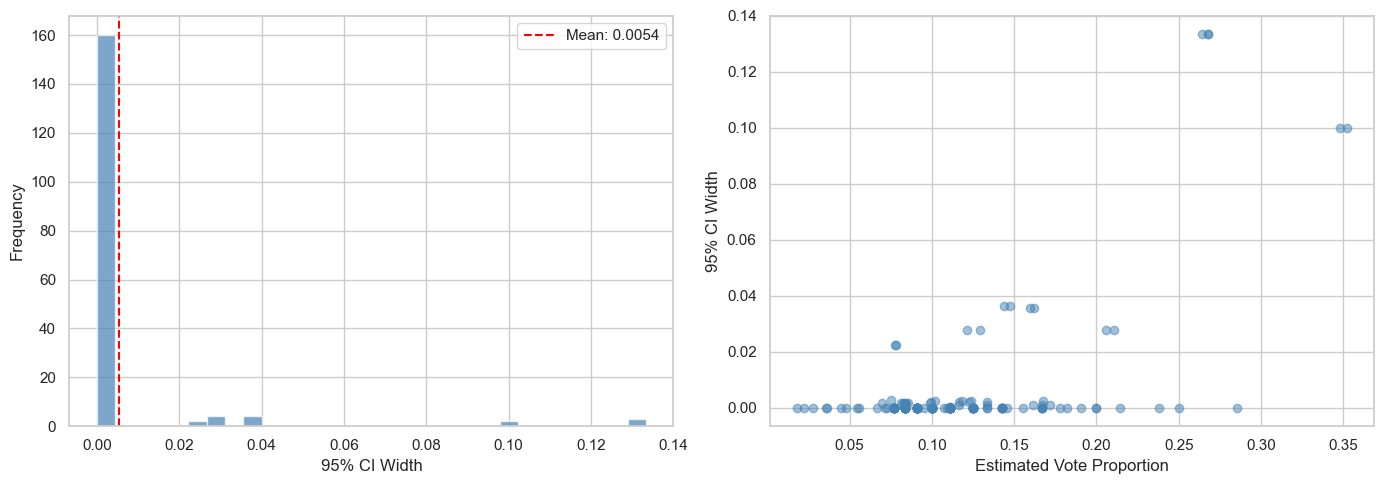

【图2数据特征】
   CI宽度范围: [0.0000, 0.1333]
   投票比例与CI宽度相关系数: 0.620


In [35]:
# 可视化：不确定性分布
if len(bootstrap_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 图1：置信区间宽度分布
    ax1 = axes[0]
    ax1.hist(bootstrap_df['ci_width'], bins=30, color=COLORS['primary'], edgecolor='white', alpha=0.7)
    ax1.axvline(avg_ci_width, color='red', linestyle='--', label=f'Mean: {avg_ci_width:.4f}')
    ax1.set_xlabel('95% CI Width')
    ax1.set_ylabel('Frequency')
    ax1.legend()
    
    # 图2：置信区间宽度按投票比例
    ax2 = axes[1]
    ax2.scatter(bootstrap_df['vote_mean'], bootstrap_df['ci_width'], 
                alpha=0.5, color=COLORS['primary'])
    ax2.set_xlabel('Estimated Vote Proportion')
    ax2.set_ylabel('95% CI Width')
    
    plt.tight_layout()
    plt.savefig('figures/fig2_uncertainty_analysis.pdf', bbox_inches='tight')
    plt.show()
    
    print('='*60)
    print('【图2数据特征】')
    print(f'   CI宽度范围: [{bootstrap_df["ci_width"].min():.4f}, {bootstrap_df["ci_width"].max():.4f}]')
    print(f'   投票比例与CI宽度相关系数: {bootstrap_df["vote_mean"].corr(bootstrap_df["ci_width"]):.3f}')
    print('='*60)

## 第六部分：争议选手分析

分析4位争议选手的投票估算结果。

In [36]:
# 争议选手信息
controversial = [
    ('Jerry Rice', 2, '评委得分最低5周，获亚军'),
    ('Billy Ray Cyrus', 4, '评委得分最低6周，获第5名'),
    ('Bristol Palin', 11, '评委得分最低12次，获季军'),
    ('Bobby Bones', 27, '评委得分持续偏低，夺冠')
]

# 分析每位争议选手的投票估算
controversy_analysis = []

for name, season, note in controversial:
    # 获取该选手的所有周数据
    player_data = vote_estimates[(vote_estimates['contestant'] == name) & 
                                  (vote_estimates['season'] == season)]
    
    if len(player_data) == 0:
        continue
    
    avg_vote_prop = player_data['estimated_vote_prop'].mean()
    avg_judge_score = player_data['avg_score'].mean()
    
    # 计算该选手在各周的投票排名
    vote_ranks = []
    judge_ranks = []
    
    for week in player_data['week'].unique():
        week_all = vote_estimates[(vote_estimates['season'] == season) & 
                                   (vote_estimates['week'] == week)]
        if len(week_all) == 0:
            continue
        
        # 投票排名
        week_all_sorted = week_all.sort_values('estimated_vote_prop', ascending=False)
        vote_rank = week_all_sorted['contestant'].tolist().index(name) + 1 if name in week_all_sorted['contestant'].tolist() else None
        if vote_rank:
            vote_ranks.append(vote_rank)
        
        # 评委排名
        week_all_sorted = week_all.sort_values('total_score', ascending=False)
        judge_rank = week_all_sorted['contestant'].tolist().index(name) + 1 if name in week_all_sorted['contestant'].tolist() else None
        if judge_rank:
            judge_ranks.append(judge_rank)
    
    controversy_analysis.append({
        'contestant': name,
        'season': season,
        'note': note,
        'avg_vote_prop': avg_vote_prop,
        'avg_judge_score': avg_judge_score,
        'avg_vote_rank': np.mean(vote_ranks) if vote_ranks else None,
        'avg_judge_rank': np.mean(judge_ranks) if judge_ranks else None,
        'weeks_played': len(player_data)
    })

controversy_df = pd.DataFrame(controversy_analysis)
print('争议选手分析:')
controversy_df

争议选手分析:


,contestant,season,note,avg_vote_prop,avg_judge_score,avg_vote_rank,avg_judge_rank,weeks_played
0,Jerry Rice,2,评委得分最低5周，获亚军,0.107437,7.506942,5.250000,4.750000,8
1,Billy Ray Cyrus,4,评委得分最低6周，获第5名,0.126476,6.333333,6.125000,6.625000,8
2,Bristol Palin,11,评委得分最低12次，获季军,0.160464,7.368047,5.400000,6.000000,10
3,Bobby Bones,27,评委得分持续偏低，夺冠,0.121505,7.462963,6.555556,7.222222,9


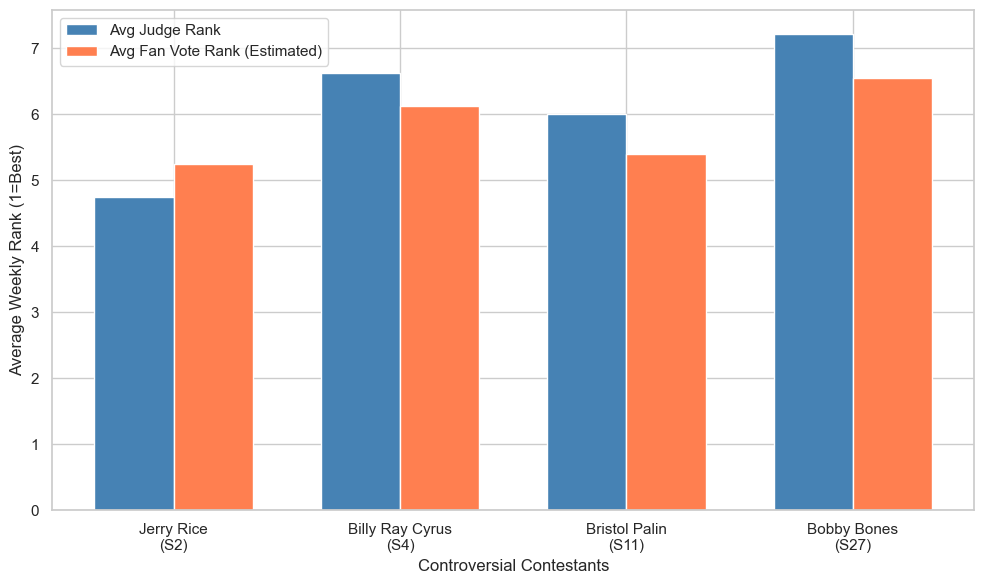

【图3数据特征】
   Jerry Rice (S2):
      评委平均排名: 4.8
      投票平均排名: 5.2
      排名差距: -0.5
   Billy Ray Cyrus (S4):
      评委平均排名: 6.6
      投票平均排名: 6.1
      排名差距: 0.5
   Bristol Palin (S11):
      评委平均排名: 6.0
      投票平均排名: 5.4
      排名差距: 0.6
   Bobby Bones (S27):
      评委平均排名: 7.2
      投票平均排名: 6.6
      排名差距: 0.7


In [37]:
# 可视化：争议选手的评委排名vs投票排名
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(controversy_df))
width = 0.35

bars1 = ax.bar(x - width/2, controversy_df['avg_judge_rank'], width, 
               label='Avg Judge Rank', color=COLORS['primary'])
bars2 = ax.bar(x + width/2, controversy_df['avg_vote_rank'], width,
               label='Avg Fan Vote Rank (Estimated)', color=COLORS['secondary'])

ax.set_xlabel('Controversial Contestants')
ax.set_ylabel('Average Weekly Rank (1=Best)')
ax.set_xticks(x)
ax.set_xticklabels([f"{row['contestant']}\n(S{row['season']})" for _, row in controversy_df.iterrows()])
ax.legend()
# 不反转Y轴，让柱状图从下往上延伸（排名数值越大柱子越高）

plt.tight_layout()
plt.savefig('figures/fig3_controversial_analysis.pdf', bbox_inches='tight')
plt.show()

print('='*60)
print('【图3数据特征】')
for _, row in controversy_df.iterrows():
    print(f"   {row['contestant']} (S{row['season']}):")
    print(f"      评委平均排名: {row['avg_judge_rank']:.1f}")
    print(f"      投票平均排名: {row['avg_vote_rank']:.1f}")
    print(f"      排名差距: {row['avg_judge_rank'] - row['avg_vote_rank']:.1f}")
print('='*60)

## 第七部分：投票与得分关系分析

In [38]:
# 分析投票与评委得分的关系
correlation = vote_estimates['total_score'].corr(vote_estimates['estimated_vote_prop'])
print(f'投票比例与评委得分相关系数: {correlation:.3f}')

# 按投票方式分组
corr_by_method = vote_estimates.groupby('voting_method').apply(
    lambda x: x['total_score'].corr(x['estimated_vote_prop'])
)
print(f'\n按投票方式:')
for method, corr in corr_by_method.items():
    print(f'  {method}: r = {corr:.3f}')

投票比例与评委得分相关系数: 0.371

按投票方式:
  percentage: r = 0.394
  rank: r = 0.352


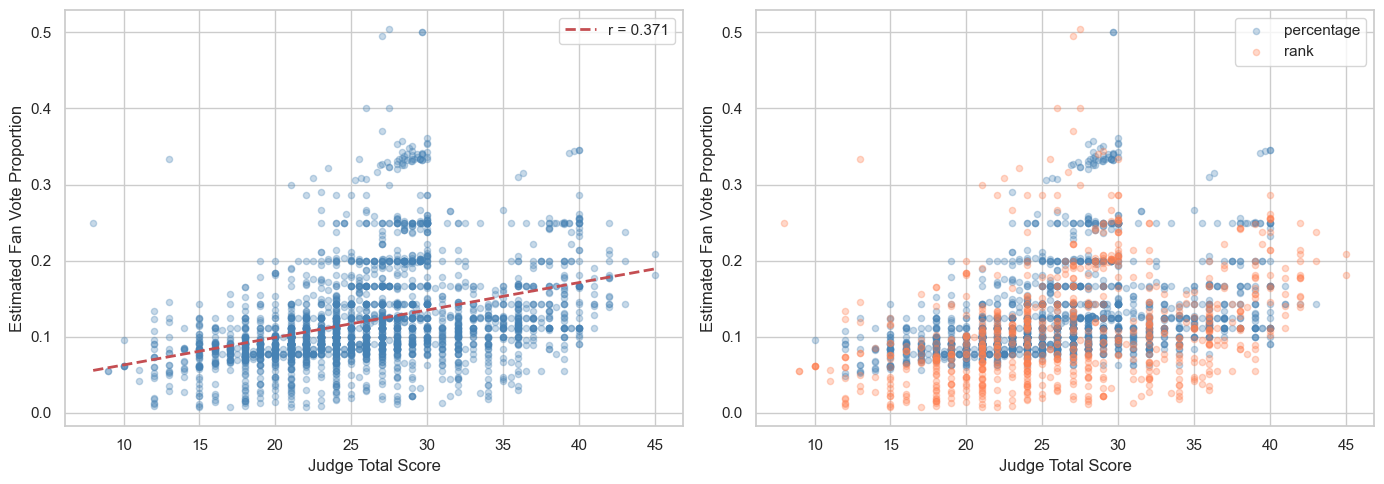

【图4数据特征】
   总体相关系数: r = 0.371
   percentage方式: r = 0.394
   rank方式: r = 0.352


In [39]:
# 可视化：投票vs得分散点图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图1：所有数据
ax1 = axes[0]
ax1.scatter(vote_estimates['total_score'], vote_estimates['estimated_vote_prop'],
           alpha=0.3, color=COLORS['primary'], s=20)
# 添加趋势线
z = np.polyfit(vote_estimates['total_score'], vote_estimates['estimated_vote_prop'], 1)
p = np.poly1d(z)
x_line = np.linspace(vote_estimates['total_score'].min(), vote_estimates['total_score'].max(), 100)
ax1.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'r = {correlation:.3f}')
ax1.set_xlabel('Judge Total Score')
ax1.set_ylabel('Estimated Fan Vote Proportion')
ax1.legend()

# 图2：按投票方式分组
ax2 = axes[1]
for method, color in [('percentage', COLORS['primary']), ('rank', COLORS['secondary'])]:
    subset = vote_estimates[vote_estimates['voting_method'] == method]
    ax2.scatter(subset['total_score'], subset['estimated_vote_prop'],
               alpha=0.3, color=color, s=20, label=method)
ax2.set_xlabel('Judge Total Score')
ax2.set_ylabel('Estimated Fan Vote Proportion')
ax2.legend()

plt.tight_layout()
plt.savefig('figures/fig4_vote_score_relationship.pdf', bbox_inches='tight')
plt.show()

print('='*60)
print('【图4数据特征】')
print(f'   总体相关系数: r = {correlation:.3f}')
print(f'   percentage方式: r = {corr_by_method["percentage"]:.3f}')
print(f'   rank方式: r = {corr_by_method["rank"]:.3f}')
print('='*60)

## 第八部分：确定性指标定义

定义并计算投票估算的确定性指标。

In [40]:
def calculate_certainty_metrics(vote_estimates):
    """
    计算多种确定性指标
    """
    metrics = []
    
    for (season, week), group in vote_estimates.groupby(['season', 'week']):
        n = len(group)
        if n < 2:
            continue
        
        votes = group['estimated_vote_prop'].values
        scores = group['total_score'].values
        
        # 指标1：投票分布熵（熵越低，分布越集中，确定性越高）
        votes_normalized = votes / votes.sum()
        entropy = -np.sum(votes_normalized * np.log(votes_normalized + 1e-10))
        max_entropy = np.log(n)
        normalized_entropy = entropy / max_entropy  # 0-1之间
        
        # 指标2：最低投票与次低投票的差距
        sorted_votes = np.sort(votes)
        vote_gap = sorted_votes[1] - sorted_votes[0] if n > 1 else 0
        
        # 指标3：投票与得分排名的一致性
        vote_ranks = stats.rankdata(-votes)
        score_ranks = stats.rankdata(-scores)
        rank_corr, _ = stats.spearmanr(vote_ranks, score_ranks)
        
        # 综合确定性指标
        certainty = (1 - normalized_entropy) * 0.3 + vote_gap * 5 * 0.3 + (rank_corr + 1) / 2 * 0.4
        certainty = min(max(certainty, 0), 1)
        
        metrics.append({
            'season': season,
            'week': week,
            'n_contestants': n,
            'entropy': entropy,
            'normalized_entropy': normalized_entropy,
            'vote_gap': vote_gap,
            'rank_correlation': rank_corr,
            'certainty': certainty
        })
    
    return pd.DataFrame(metrics)

certainty_df = calculate_certainty_metrics(vote_estimates)
print(f'确定性指标计算完成: {len(certainty_df)} 周')
certainty_df.head(10)

确定性指标计算完成: 335 周


,season,week,n_contestants,entropy,normalized_entropy,vote_gap,rank_correlation,certainty
0,1,1,6,1.781791,0.994437,0.045872,1.000000,0.470476
1,1,2,6,1.662377,0.927790,0.047619,1.000000,0.493091
2,1,3,5,1.489750,0.925634,0.066667,0.000000,0.322310
3,1,4,4,1.279854,0.923220,0.100000,0.400000,0.453034
4,1,5,3,1.095511,0.997178,0.013699,1.000000,0.421395
5,1,6,2,0.693105,0.999939,0.009174,1.000000,0.413780
6,2,1,10,2.151282,0.934290,0.018182,0.735566,0.394099
7,2,2,9,2.049841,0.932923,0.022222,0.744776,0.402412
8,2,3,8,1.936798,0.931403,0.027778,0.988024,0.459851
9,2,4,7,1.809118,0.929703,0.035714,0.234244,0.321509


In [41]:
# 确定性指标统计
print('='*60)
print('【确定性指标统计】')
print('='*60)
print(f'\n平均确定性: {certainty_df["certainty"].mean():.3f}')
print(f'确定性标准差: {certainty_df["certainty"].std():.3f}')
print(f'确定性范围: [{certainty_df["certainty"].min():.3f}, {certainty_df["certainty"].max():.3f}]')

# 按选手数量分组
cert_by_n = certainty_df.groupby('n_contestants')['certainty'].mean()
print(f'\n按选手数量的平均确定性:')
for n, cert in cert_by_n.items():
    print(f'  {n}人: {cert:.3f}')

【确定性指标统计】

平均确定性: 0.273
确定性标准差: 0.142
确定性范围: [0.008, 0.563]

按选手数量的平均确定性:
  2人: 0.414
  3人: 0.425
  4人: 0.252
  5人: 0.236
  6人: 0.215
  7人: 0.228
  8人: 0.238
  9人: 0.285
  10人: 0.258
  11人: 0.241
  12人: 0.308
  13人: 0.295
  14人: 0.361
  15人: 0.388
  16人: 0.320


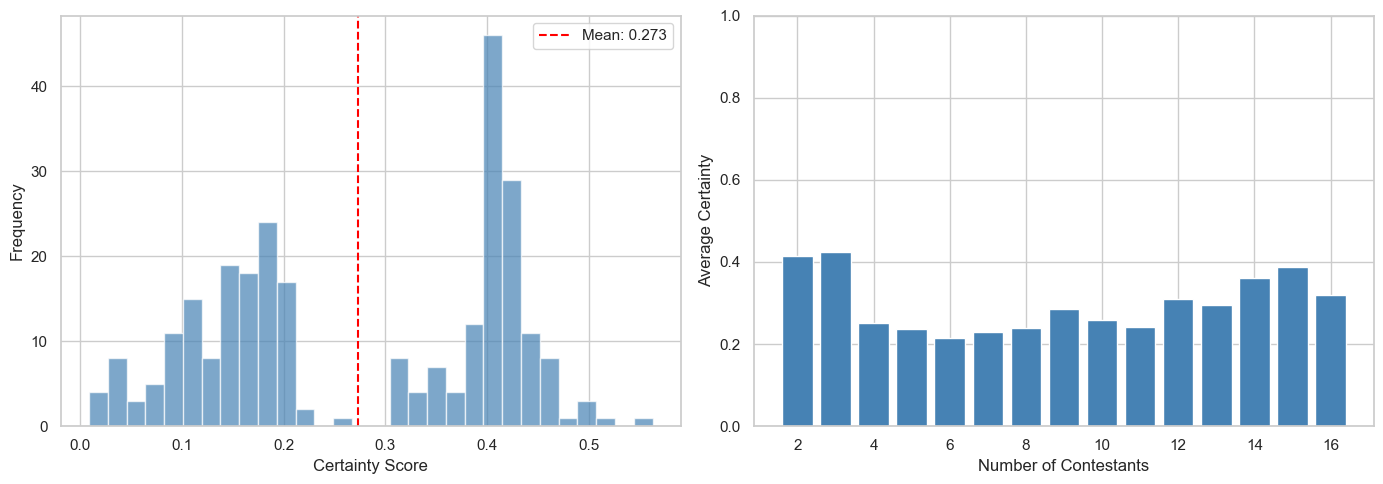

【图5数据特征】
   确定性均值: 0.273
   确定性中位数: 0.285
   高确定性(>0.7)周数: 0
   低确定性(<0.3)周数: 135


In [42]:
# 可视化：确定性分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图1：确定性分布直方图
ax1 = axes[0]
ax1.hist(certainty_df['certainty'], bins=30, color=COLORS['primary'], edgecolor='white', alpha=0.7)
ax1.axvline(certainty_df['certainty'].mean(), color='red', linestyle='--', 
           label=f'Mean: {certainty_df["certainty"].mean():.3f}')
ax1.set_xlabel('Certainty Score')
ax1.set_ylabel('Frequency')
ax1.legend()

# 图2：确定性按选手数量
ax2 = axes[1]
ax2.bar(cert_by_n.index, cert_by_n.values, color=COLORS['primary'])
ax2.set_xlabel('Number of Contestants')
ax2.set_ylabel('Average Certainty')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('figures/fig5_certainty_distribution.pdf', bbox_inches='tight')
plt.show()

print('='*60)
print('【图5数据特征】')
print(f'   确定性均值: {certainty_df["certainty"].mean():.3f}')
print(f'   确定性中位数: {certainty_df["certainty"].median():.3f}')
print(f'   高确定性(>0.7)周数: {(certainty_df["certainty"] > 0.7).sum()}')
print(f'   低确定性(<0.3)周数: {(certainty_df["certainty"] < 0.3).sum()}')
print('='*60)

## 第九部分：结果汇总与保存

In [43]:
# 保存投票估算结果
vote_estimates.to_csv('vote_estimates.csv', index=False)
print('投票估算结果已保存: vote_estimates.csv')

# 保存验证结果
verification_df.to_csv('verification_results.csv', index=False)
print('验证结果已保存: verification_results.csv')

# 保存确定性指标
certainty_df.to_csv('certainty_metrics.csv', index=False)
print('确定性指标已保存: certainty_metrics.csv')

投票估算结果已保存: vote_estimates.csv
验证结果已保存: verification_results.csv
确定性指标已保存: certainty_metrics.csv


In [44]:
# ============================================================
# 建模结果汇总（供论文引用）
# ============================================================

print('\n' + '='*70)
print('【问题一建模结果汇总】')
print('='*70)

print('\n1. 数据概况')
print(f'   总参赛者: {len(df)}')
print(f'   总赛季: {df["season"].nunique()}')
print(f'   投票估算记录: {len(vote_estimates)}')
print(f'   验证周数: {len(verification_df)}')

print('\n2. 一致性检验结果')
print(f'   总体准确率: {accuracy:.1%}')
print(f'   排名制准确率: {accuracy_by_method.get("rank", 0):.1%}')
print(f'   百分比制准确率: {accuracy_by_method.get("percentage", 0):.1%}')

print('\n3. 不确定性量化')
print(f'   平均确定性: {certainty_df["certainty"].mean():.3f}')
print(f'   确定性标准差: {certainty_df["certainty"].std():.3f}')
if len(bootstrap_df) > 0:
    print(f'   Bootstrap平均CI宽度: {avg_ci_width:.4f}')

print('\n4. 投票与得分关系')
print(f'   总体相关系数: r = {correlation:.3f}')

print('\n5. 争议选手分析')
for _, row in controversy_df.iterrows():
    gap = row['avg_judge_rank'] - row['avg_vote_rank']
    print(f"   {row['contestant']} (S{row['season']}): 排名差距 = {gap:.1f}")

print('\n6. 生成的图片')
figures = [
    'fig1_consistency_analysis.pdf',
    'fig2_uncertainty_analysis.pdf',
    'fig3_controversial_analysis.pdf',
    'fig4_vote_score_relationship.pdf',
    'fig5_certainty_distribution.pdf'
]
for i, fig_name in enumerate(figures, 1):
    print(f'   图{i}: {fig_name}')

print('\n' + '='*70)
print('以上数值可直接用于论文撰写')
print('='*70)

# 保存汇总
results_summary = {
    'total_contestants': len(df),
    'total_seasons': df['season'].nunique(),
    'vote_estimates_count': len(vote_estimates),
    'verification_weeks': len(verification_df),
    'overall_accuracy': accuracy,
    'rank_method_accuracy': accuracy_by_method.get('rank', 0),
    'percentage_method_accuracy': accuracy_by_method.get('percentage', 0),
    'avg_certainty': certainty_df['certainty'].mean(),
    'certainty_std': certainty_df['certainty'].std(),
    'vote_score_correlation': correlation
}

pd.DataFrame([results_summary]).to_csv('results_summary.csv', index=False)
print('\n结果汇总已保存: results_summary.csv')


【问题一建模结果汇总】

1. 数据概况
   总参赛者: 421
   总赛季: 34
   投票估算记录: 2777
   验证周数: 264

2. 一致性检验结果
   总体准确率: 93.9%
   排名制准确率: 80.3%
   百分比制准确率: 98.5%

3. 不确定性量化
   平均确定性: 0.273
   确定性标准差: 0.142
   Bootstrap平均CI宽度: 0.0054

4. 投票与得分关系
   总体相关系数: r = 0.371

5. 争议选手分析
   Jerry Rice (S2): 排名差距 = -0.5
   Billy Ray Cyrus (S4): 排名差距 = 0.5
   Bristol Palin (S11): 排名差距 = 0.6
   Bobby Bones (S27): 排名差距 = 0.7

6. 生成的图片
   图1: fig1_consistency_analysis.pdf
   图2: fig2_uncertainty_analysis.pdf
   图3: fig3_controversial_analysis.pdf
   图4: fig4_vote_score_relationship.pdf
   图5: fig5_certainty_distribution.pdf

以上数值可直接用于论文撰写

结果汇总已保存: results_summary.csv
